# 4 Model Evaluation

This notebook loads our own finetuned Whisper model and then evaluates it.

In [2]:
# Cell 1: Imports & Setup
import sys, os
from pathlib import Path
import torch

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

from whisper_asr import transcribe_whisper, compute_idiom_results, print_evaluation_results, plot_wer_violin, load_all_data, compute_normalized_results
from whisper_asr.utils import get_best_gpu
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer, cer
import random

os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL_PATH = "../models/whisper-medium-rm-all-it"
DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8

print(f"Using device: {DEVICE}")

Selected GPU 7 with 24121 MiB free memory
Using device: cuda:7


In [3]:
# Cell 2: Load Model
processor = WhisperProcessor.from_pretrained(MODEL_PATH)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_PATH).to(DEVICE)
print("Model loaded.")

Loading weights: 100%|██████████| 947/947 [00:00<00:00, 8983.78it/s]


Model loaded.


In [4]:
# Cell 3: Load Test Data
test_df = load_all_data("test")
audio_paths = test_df["audio_path"]
references = test_df["sentence"]
idioms = test_df["idiom"]

In [5]:
# Cell 4: Transcribe
transcriptions = transcribe_whisper(model, processor, audio_paths, batch_size=BATCH_SIZE, device=DEVICE)

Transcribing (Whisper):   0%|          | 0/79 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom 

In [6]:
# Cell 5: Compute & Display Results
summary_df, overall_wer, overall_cer, valid_pairs = compute_idiom_results(references, transcriptions, idioms)
print_evaluation_results(summary_df, overall_wer, overall_cer, len(audio_paths), len(valid_pairs))


OVERALL RESULTS
Total test samples: 631
Valid pairs: 631/631

Word Error Rate (WER): 0.1925 (19.25%)
Character Error Rate (CER): 0.0626 (6.26%)

PER IDIOM RESULTS

SURMIRAN
  Samples: 151
  WER: 0.1731 (17.31%)
  CER: 0.0551 (5.51%)

SUTSILVAN
  Samples: 94
  WER: 0.2387 (23.87%)
  CER: 0.0818 (8.18%)

PUTER
  Samples: 114
  WER: 0.1646 (16.46%)
  CER: 0.0433 (4.33%)

RG
  Samples: 81
  WER: 0.0883 (8.83%)
  CER: 0.0237 (2.37%)

VALLADER
  Samples: 97
  WER: 0.2627 (26.27%)
  CER: 0.1092 (10.92%)

SURSILVAN
  Samples: 94
  WER: 0.2211 (22.11%)
  CER: 0.0655 (6.55%)

SUMMARY TABLE
    idiom  samples      wer      cer
 Surmiran      151 0.173077 0.055101
Sutsilvan       94 0.238663 0.081798
    Puter      114 0.164623 0.043321
       RG       81 0.088346 0.023717
 Vallader       97 0.262663 0.109249
Sursilvan       94 0.221079 0.065461


/local/scratch/matuor/whisper/whisper_asr/analysis.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/local/scratch/matuor/whisper/whisper_asr/analysis.py:95: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


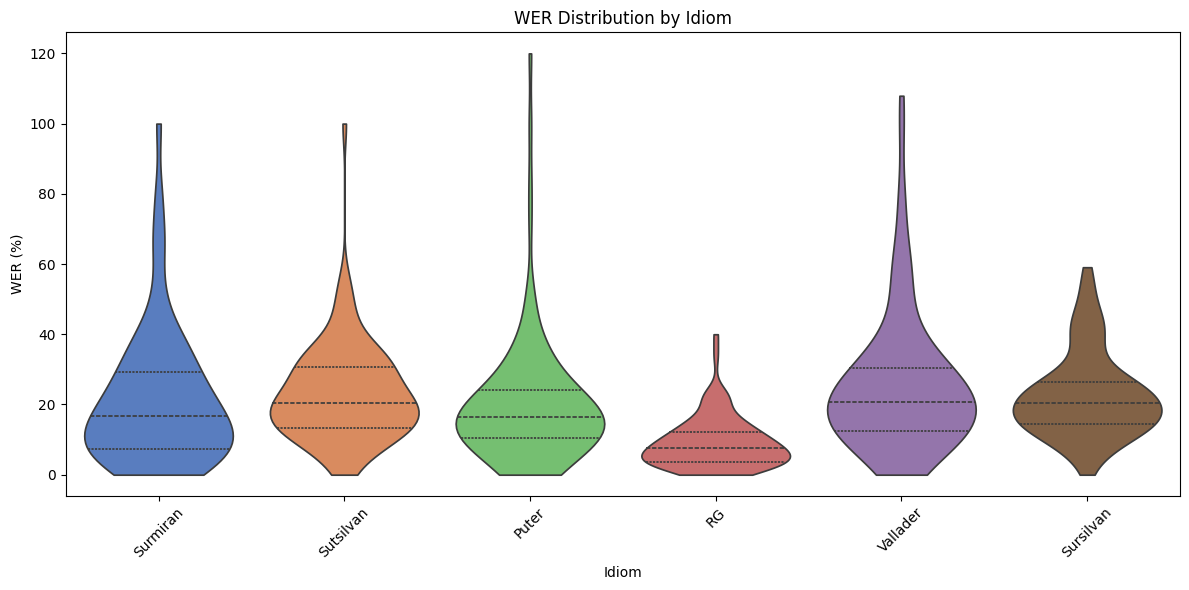

In [7]:
# Cell 6: Violin Plot
plot_wer_violin(references, transcriptions, idioms)

In [8]:
sample_indices = random.sample(range(len(valid_pairs)), min(5, len(valid_pairs)))

for i, idx in enumerate(sample_indices):
    print(f"\n--- Sample {i+1} ---")
    print(f"Reference: {references[idx]}")
    print(f"Hypothesis: {transcriptions[idx]}")
    sample_wer, sample_cer = wer(references[idx], transcriptions[idx]), cer(references[idx], transcriptions[idx])
    print(f"Sample WER: {sample_wer:.4f}, Sample CER: {sample_cer:.4f}")
    print("-" * 40)


--- Sample 1 ---
Reference: Vus vesis era sch'ei dracca giu il tschiel, la glieud vegn perquei tuttina. Sche vus haveis ussa era survegniu gust ed essas cunzun spontans e sperts. Ils artists ein cheu a Cuera tochen oz in quart avon las dudisch. Quei eis ei stau dil Minisguard per oz. Jeu giavischel a vus ina biala sera ed uss mein nus aunc a dar ina egliada. Vegni!
Hypothesis: Vus vesis era schi dracca giu el tschiel, la glieud vegn per quei tuttina. Sche vus haveis uss era survegniu gust ed essas cunzun spontans e sperts, ils artists ein cheu a Cuera tochen oz in quart avon las 12. Quei eis ei stau dil Minisguard per oz, jeu giavischel a vus ina biala sera ed uss mein nus aunc adai ina jada, vegni.
Sample WER: 0.2188, Sample CER: 0.0737
----------------------------------------

--- Sample 2 ---
Reference: I'ls ans 80, cur cha’ls rumauntschs planisaivan e discuttaivan per fer üna giazetta quotidiana rumauntscha, ho Hanspeter Lebrument, il posessur da la Gasser, cumpro stamparias e tit

In [9]:
norm_summary_df, overall_norm_wer, overall_norm_cer, norm_valid_pairs = compute_normalized_results(
    references, transcriptions, idioms
)
print_evaluation_results(
    norm_summary_df, overall_norm_wer, overall_norm_cer, len(test_df), len(norm_valid_pairs)
)


OVERALL RESULTS
Total test samples: 631
Valid pairs: 631/631

Word Error Rate (WER): 0.1288 (12.88%)
Character Error Rate (CER): 0.0479 (4.79%)

PER IDIOM RESULTS

SURMIRAN
  Samples: 151
  WER: 0.1125 (11.25%)
  CER: 0.0411 (4.11%)

SUTSILVAN
  Samples: 94
  WER: 0.1731 (17.31%)
  CER: 0.0657 (6.57%)

PUTER
  Samples: 114
  WER: 0.1042 (10.42%)
  CER: 0.0300 (3.00%)

RG
  Samples: 81
  WER: 0.0443 (4.43%)
  CER: 0.0150 (1.50%)

VALLADER
  Samples: 97
  WER: 0.1886 (18.86%)
  CER: 0.0916 (9.16%)

SURSILVAN
  Samples: 94
  WER: 0.1452 (14.52%)
  CER: 0.0473 (4.73%)

SUMMARY TABLE
    idiom  samples      wer      cer
 Surmiran      151 0.112481 0.041065
Sutsilvan       94 0.173140 0.065656
    Puter      114 0.104247 0.030017
       RG       81 0.044287 0.014991
 Vallader       97 0.188575 0.091573
Sursilvan       94 0.145175 0.047277
